In [28]:
import pyvista as pv #in source ~/venvs/my-umap-env/bin/activate
pv.set_jupyter_backend('client')

In [2]:
# import sys
# print(sys.executable)
# !{sys.executable} -m pip install -U trame-pyvista trame trame-vtk trame-vuetify nest-asyncio2

In [3]:
# %pip install trame-pyvista trame-jupyter-extension
# %pip install "trame-pyvista[jupyter]"

In [4]:
import numpy as np
from astropy.table import Table
from astropy.table import join

from astropy.io import fits
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')
import seaborn as sns

In [5]:
#!ls $PSCRATCH/cosmic-web/dr1/classification/bgs/ngc

In [6]:
!$PSCRATCH

/bin/bash: /pscratch/sd/v/vtorresg: Is a directory


In [7]:
tab = Table.read('/pscratch/sd/v/vtorresg/cosmic-web/dr1/classification/lrg/ngc/zone_NGC_LRG_iter000.fits.gz')
tab[:10]

TARGETID,RANDITER,ISDATA,NDATA,NRAND,TRACER_ID,TRACERTYPE
int64,int32,bool,int32,int32,uint8,bytes24
39627540901396844,0,True,30,35,3,LRG
39627546836338876,0,True,21,25,3,LRG
39627546840531340,0,True,13,19,3,LRG
39627546840533707,0,True,5,9,3,LRG
39627546840534067,0,True,6,10,3,LRG
39627546840534396,0,True,22,16,3,LRG
39627546844725593,0,True,14,22,3,LRG
39627546844726132,0,True,9,11,3,LRG
39627546844726593,0,True,8,12,3,LRG


In [8]:
tab['r'] = (tab['NDATA'] - tab['NRAND']) / (tab['NDATA'] + tab['NRAND'])
tab['r']

-0.07692307692307693
-0.08695652173913043
-0.1875
-0.2857142857142857
-0.25
0.15789473684210525
-0.2222222222222222
-0.1
-0.2
0.23076923076923078
0.125


In [9]:
rand = tab[tab['ISDATA']==False]
len(rand), len(tab[tab['ISDATA']==True])

(1476135, 1476135)

In [10]:
np.min(rand['r']), np.max(rand['r'])

(np.float64(-1.0), np.float64(1.0))

In [11]:
rand_voids = rand[rand['r']<-0.25]
len(rand_voids)

601342

In [12]:
rand_voids[:10]

TARGETID,RANDITER,ISDATA,NDATA,NRAND,TRACER_ID,TRACERTYPE,r
int64,int32,bool,int32,int32,uint8,bytes24,float64
327858012825847460,0,False,5,10,3,LRG,-0.3333333333333333
327863848126120100,0,False,7,14,3,LRG,-0.3333333333333333
327858562975924649,0,False,4,16,3,LRG,-0.6
327858267558512672,0,False,4,11,3,LRG,-0.4666666666666667
327863584740608127,0,False,2,13,3,LRG,-0.7333333333333333
327858610413504800,0,False,4,7,3,LRG,-0.2727272727272727
327863429928847487,0,False,5,13,3,LRG,-0.4444444444444444
327863665371907919,0,False,1,16,3,LRG,-0.8823529411764706
327863392314329021,0,False,1,11,3,LRG,-0.8333333333333334


In [13]:
len(rand_voids)/len(rand)

0.40737601913104154

In [14]:
!ls /pscratch/sd/v/vtorresg/cosmic-web/dr1/raw

zone_NGC_BGS_ANY.fits.gz     zone_NGC_QSO.fits.gz	  zone_SGC_ELG.fits.gz
zone_NGC_BGS_BRIGHT.fits.gz  zone_QSO.tar.gz		  zone_SGC_LRG.fits.gz
zone_NGC_ELG.fits.gz	     zone_SGC_BGS_ANY.fits.gz	  zone_SGC_QSO.fits.gz
zone_NGC_LRG.fits.gz	     zone_SGC_BGS_BRIGHT.fits.gz


In [15]:
!du -sh /pscratch/sd/v/vtorresg/cosmic-web/dr1/raw/zone_NGC_LRG.fits.gz

8.2G	/pscratch/sd/v/vtorresg/cosmic-web/dr1/raw/zone_NGC_LRG.fits.gz


In [16]:
raw = Table.read('/pscratch/sd/v/vtorresg/cosmic-web/dr1/raw/zone_NGC_LRG.fits.gz')
raw = raw[raw['RANDITER']==0]
raw[:10]

TARGETID,RA,DEC,Z,XCART,YCART,ZCART,RANDITER,TRACER_ID,TRACERTYPE
int64,float32,float32,float32,float32,float32,float32,int16,uint8,bytes24
327858012825847460,163.2464,-6.287139,0.9192842,-3036.3977,914.0601,-349.3608,0,3,LRG
327863848126120100,138.31145,68.0976,0.7047793,-722.43066,643.4034,2406.2065,0,3,LRG
327858134058010476,201.49707,-1.3368491,0.5463562,-1953.388,-769.3446,-48.99372,0,3,LRG
327858049974797424,225.6887,-4.645967,0.91060925,-2205.4148,-2259.0815,-256.56396,0,3,LRG
327858562975924649,166.42522,16.822823,0.5818087,-2060.5918,497.54974,640.9298,0,3,LRG
327858267558512672,241.0781,4.367429,0.8569737,-1458.5471,-2639.7676,230.33733,0,3,LRG
327858261313192870,228.07463,4.075338,0.76917225,-1853.2853,-2063.6812,197.62175,0,3,LRG
327858476703287682,250.79056,13.019534,0.64468026,-773.1379,-2218.972,543.3389,0,3,LRG
327858055196706129,177.89671,-4.4367003,0.42413676,-1679.4346,61.67854,-130.39546,0,3,LRG


In [17]:
print(np.unique(raw['TARGETID']).size, np.unique(rand_voids['TARGETID']).size)
print(len(raw), len(rand_voids))

1476135 601342
1476135 601342


In [18]:
vtab = join(raw, rand_voids, keys="TARGETID", join_type="inner")
len(vtab)

601342

In [19]:
vtab[:10]

TARGETID,RA,DEC,Z,XCART,YCART,ZCART,RANDITER_1,TRACER_ID_1,TRACERTYPE_1,RANDITER_2,ISDATA,NDATA,NRAND,TRACER_ID_2,TRACERTYPE_2,r
int64,float32,float32,float32,float32,float32,float32,int16,uint8,bytes24,int32,bool,int32,int32,uint8,bytes24,float64
327857917053108239,159.25809,-10.154334,0.9570109,-3026.2036,1146.0376,-579.5754,0,3,LRG,0,False,26,47,3,LRG,-0.2876712328767123
327857917053111097,159.29514,-10.127549,0.892068,-2871.7832,1085.435,-548.38525,0,3,LRG,0,False,22,38,3,LRG,-0.26666666666666666
327857923000632532,159.10318,-10.032228,0.54560906,-1929.6315,736.7319,-365.39978,0,3,LRG,0,False,15,28,3,LRG,-0.3023255813953488
327857923000633822,159.0073,-9.92451,0.8362391,-2729.7603,1047.4581,-511.57828,0,3,LRG,0,False,3,7,3,LRG,-0.4
327857923000634119,159.11548,-9.983665,1.0925645,-3330.5544,1270.7842,-627.51483,0,3,LRG,0,False,8,25,3,LRG,-0.5151515151515151
327857923004825694,159.35991,-10.008201,0.9098728,-2917.3135,1098.8763,-550.1436,0,3,LRG,0,False,7,12,3,LRG,-0.2631578947368421
327857923004826051,159.2958,-9.9985,0.5502062,-1946.1202,735.54034,-366.78888,0,3,LRG,0,False,5,11,3,LRG,-0.375
327857923004826068,159.24925,-9.9270935,0.8472458,-2761.822,1046.402,-516.8914,0,3,LRG,0,False,5,16,3,LRG,-0.5238095238095238
327857923004826675,159.27116,-10.04014,0.526629,-1874.2762,709.30817,-354.80768,0,3,LRG,0,False,18,37,3,LRG,-0.34545454545454546


In [20]:
np.min(vtab['XCART']), np.max(vtab['XCART'])

(np.float32(-3632.3357), np.float32(654.4967))

In [21]:
np.min(vtab['YCART']), np.max(vtab['YCART'])

(np.float32(-3505.442), np.float32(3073.7837))

In [22]:
np.min(vtab['ZCART']), np.max(vtab['ZCART'])

(np.float32(-627.51483), np.float32(3545.3284))

In [23]:
x0 = 0.5 * (np.min(vtab['XCART']) + np.max(vtab['XCART']))
y0 = 0.5 * (np.min(vtab['YCART']) + np.max(vtab['YCART']))
z0 = 0.5 * (np.min(vtab['ZCART']) + np.max(vtab['ZCART']))

half_size = 100

mask = ((vtab['XCART'] >= x0 - half_size) & (vtab['XCART'] <= x0 + half_size) &
        (vtab['YCART'] >= y0 - half_size) & (vtab['YCART'] <= y0 + half_size) &
        (vtab['ZCART'] >= z0 - half_size) & (vtab['ZCART'] <= z0 + half_size))

vcenter = vtab[mask]

In [24]:
len(vcenter)

137

In [25]:
points = np.column_stack([vcenter['XCART'], vcenter['YCART'], vcenter['ZCART']])
points.size

411

In [26]:
center = points.mean(axis=0)

In [27]:
# points_norm = (points - center) / R_eff # norm por r_eff

In [29]:
cloud = pv.PolyData(points)

In [30]:
plotter = pv.Plotter(notebook=True)
plotter.add_points(cloud, point_size=4, render_points_as_spheres=True)

plotter.add_axes()
plotter.show_grid()
plotter.show()

2026-10-01 17:00:22.648 ( 155.725s) [    7F390824BB80]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Widget(value='<iframe src="/user/vtorresg/perlmutter-exclusive-node-cpu/proxy/36209/index.html?ui=P_0x7f37698c…

Exception raised
KeyError('59595d4b3607bd7dfe82e5753b195b12_274L')
Traceback (most recent call last):
  File "/global/homes/v/vtorresg/venvs/my-umap-env/lib/python3.13/site-packages/wslink/protocol.py", line 317, in onCompleteMessage
    results = func(*args, **kwargs)
  File "/global/homes/v/vtorresg/venvs/my-umap-env/lib/python3.13/site-packages/trame_vtk/modules/vtk/protocols/local_rendering.py", line 33, in get_array
    self.context.get_cached_data_array(data_hash, binary)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/global/homes/v/vtorresg/venvs/my-umap-env/lib/python3.13/site-packages/trame_vtk/modules/vtk/serializers/synchronization_context.py", line 47, in get_cached_data_array
    cache_obj = self.data_array_cache[p_md5]
                ~~~~~~~~~~~~~~~~~~~~~^^^^^^^
KeyError: '59595d4b3607bd7dfe82e5753b195b12_274L'

Exception raised
KeyError('59595d4b3607bd7dfe82e5753b195b12_274L')
Traceback (most recent call last):
  File "/global/homes/v/vtorresg/venvs/

In [31]:
# Alpha shape / Delaunay 3D
volume = cloud.delaunay_3d(alpha=0.15)

# superficie externa
surface = volume.extract_surface(algorithm=None)

In [32]:
plotter = pv.Plotter(notebook=True)

plotter.add_mesh(surface, opacity=1, show_edges=True)
plotter.add_points(cloud, point_size=3)

plotter.add_axes()
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="/user/vtorresg/perlmutter-exclusive-node-cpu/proxy/36209/index.html?ui=P_0x7f383a58…

In [46]:
Reff = 92.4989
xc, yc, zc = -1394.0683, 1797.4076, 556.7836

dx = vtab['XCART'] - (xc-0)
dy = vtab['YCART'] - (yc-0)
dz = vtab['ZCART'] - (zc-0)

r = np.sqrt(dx**2 + dy**2 + dz**2)

sub = vtab[r <= Reff]

print(len(sub))

119


In [ ]:
# points_norm = (points - center) / R_eff # norm por r_eff

In [51]:
points = np.column_stack([sub['XCART'], sub['YCART'], sub['ZCART']])

center = points.mean(axis=0)
points_norm = (points - center) / Reff # norm por r_eff

cloud = pv.PolyData(points_norm)

In [52]:
plotter = pv.Plotter(notebook=True, off_screen=True, window_size=(900,700))
plotter.add_points(cloud, point_size=5, render_points_as_spheres=True)

plotter.add_axes()
plotter.show_grid()

plotter.show()

Widget(value='<iframe src="/user/vtorresg/perlmutter-exclusive-node-cpu/proxy/36209/index.html?ui=P_0x7f37885b…

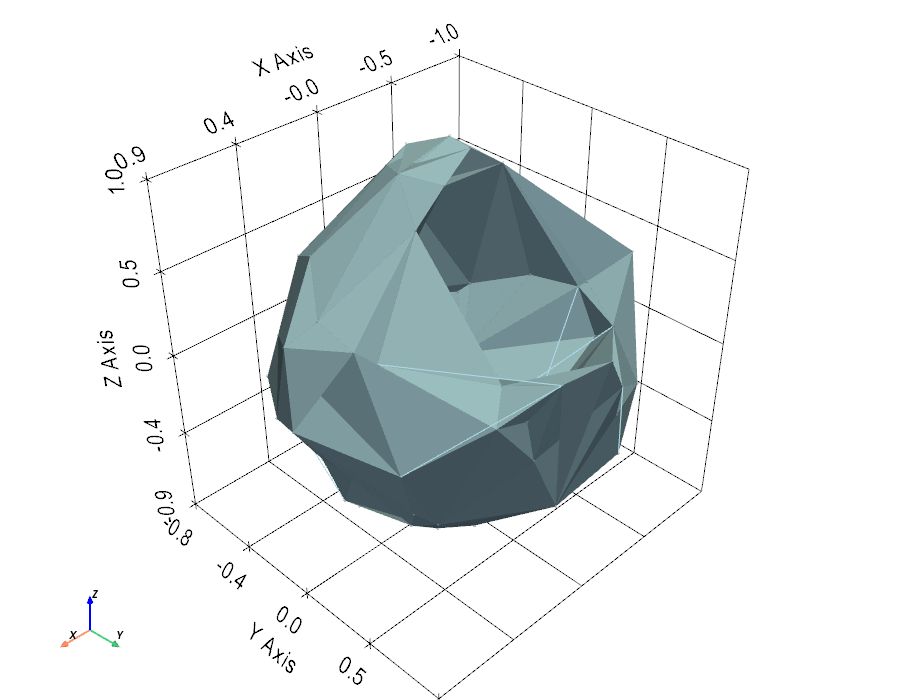

In [62]:
volume = cloud.delaunay_3d(alpha=0.4)

surface = volume.extract_surface(algorithm=None)
plotter = pv.Plotter(notebook=True, off_screen=True, window_size=(900, 700))

plotter.add_mesh(surface, opacity=1, show_edges=True)
plotter.add_points(cloud, point_size=3, opacity=0.4, render_points_as_spheres=True)

plotter.add_axes()
plotter.show_grid()

plotter.show(jupyter_backend="static")

In [63]:
vtab

TARGETID,RA,DEC,Z,XCART,YCART,ZCART,RANDITER_1,TRACER_ID_1,TRACERTYPE_1,RANDITER_2,ISDATA,NDATA,NRAND,TRACER_ID_2,TRACERTYPE_2,r
int64,float32,float32,float32,float32,float32,float32,int16,uint8,bytes24,int32,bool,int32,int32,uint8,bytes24,float64
327857917053108239,159.25809,-10.154334,0.9570109,-3026.2036,1146.0376,-579.5754,0,3,LRG,0,False,26,47,3,LRG,-0.2876712328767123
327857917053111097,159.29514,-10.127549,0.892068,-2871.7832,1085.435,-548.38525,0,3,LRG,0,False,22,38,3,LRG,-0.26666666666666666
327857923000632532,159.10318,-10.032228,0.54560906,-1929.6315,736.7319,-365.39978,0,3,LRG,0,False,15,28,3,LRG,-0.3023255813953488
327857923000633822,159.0073,-9.92451,0.8362391,-2729.7603,1047.4581,-511.57828,0,3,LRG,0,False,3,7,3,LRG,-0.4
327857923000634119,159.11548,-9.983665,1.0925645,-3330.5544,1270.7842,-627.51483,0,3,LRG,0,False,8,25,3,LRG,-0.5151515151515151
327857923004825694,159.35991,-10.008201,0.9098728,-2917.3135,1098.8763,-550.1436,0,3,LRG,0,False,7,12,3,LRG,-0.2631578947368421
327857923004826051,159.2958,-9.9985,0.5502062,-1946.1202,735.54034,-366.78888,0,3,LRG,0,False,5,11,3,LRG,-0.375
327857923004826068,159.24925,-9.9270935,0.8472458,-2761.822,1046.402,-516.8914,0,3,LRG,0,False,5,16,3,LRG,-0.5238095238095238
327857923004826675,159.27116,-10.04014,0.526629,-1874.2762,709.30817,-354.80768,0,3,LRG,0,False,18,37,3,LRG,-0.34545454545454546
